<a id="section1"></a>
## 1. Load Required Libraries

In [33]:
# Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import joblib

# SHAP for explainability
import shap

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ All libraries imported successfully!")
print(f"SHAP version: {shap.__version__}")

✓ All libraries imported successfully!
SHAP version: 0.50.0


<a id="section2"></a>
## 2. Load Trained Models

In [34]:
# Load models and preprocessing objects
models_dir = Path('models')

if not models_dir.exists():
    print("⚠ ERROR: Models directory not found!")
    print("Please run Notebook 1 first to train and save the models.")
else:
    print("="*80)
    print("LOADING TRAINED MODELS")
    print("="*80)
    
    # Load models
    xgb_model = joblib.load(models_dir / 'xgboost_model.pkl')
    elastic_model = joblib.load(models_dir / 'elastic_net_model.pkl')
    scaler = joblib.load(models_dir / 'scaler.pkl')
    feature_info = joblib.load(models_dir / 'feature_info.pkl')
    model_params = joblib.load(models_dir / 'model_parameters.pkl')
    
    print("✓ XGBoost model loaded")
    print("✓ Elastic Net model loaded")
    print("✓ Scaler loaded")
    print("✓ Feature information loaded")
    
    print(f"\nModel Information:")
    print(f"  - Number of features: {feature_info['n_features']}")
    print(f"  - Target transformation: {feature_info['target_transformation']}")
    print(f"  - XGBoost CV RMSE: {model_params['xgb_cv_rmse']}")
    print(f"  - Elastic Net CV RMSE: {model_params['elastic_cv_rmse']}")

LOADING TRAINED MODELS
✓ XGBoost model loaded
✓ Elastic Net model loaded
✓ Scaler loaded
✓ Feature information loaded

Model Information:
  - Number of features: 187
  - Target transformation: log1p
  - XGBoost CV RMSE: 0.1290 (+/- 0.0161)
  - Elastic Net CV RMSE: 0.1486 (+/- 0.0418)


<a id="section3"></a>
## 3. User Input for House Features

**Option 1:** Use a house from the test dataset  
**Option 2:** Manually input custom house features

In [35]:
# Load test data to select a sample house
data_path = Path('./dataset')
test_df = pd.read_csv(data_path / 'test.csv')

print("="*80)
print("SELECT A HOUSE FOR PREDICTION")
print("="*80)
print(f"\nAvailable houses in test set: {len(test_df)}")
print("\nShowing first 5 houses:")
print(test_df[['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'YearBuilt', 'GrLivArea']].head())

# Select a house by index (you can change this)
house_index = 0  # Change this to select different houses (0 to len(test_df)-1)

print(f"\n✓ Selected house at index {house_index} (ID: {test_df.iloc[house_index]['Id']})")

SELECT A HOUSE FOR PREDICTION

Available houses in test set: 1459

Showing first 5 houses:
     Id  MSSubClass  LotArea  OverallQual  YearBuilt  GrLivArea
0  1461          20    11622            5       1961        896
1  1462          20    14267            6       1958       1329
2  1463          60    13830            5       1997       1629
3  1464          60     9978            6       1998       1604
4  1465         120     5005            8       1992       1280

✓ Selected house at index 0 (ID: 1461)


In [36]:
# USER INPUT: Change house_index above or modify features manually here

# Display key features of the selected house
selected_house_id = test_df.iloc[house_index]['Id']

print("="*80)
print(f"SELECTED HOUSE DETAILS (ID: {selected_house_id})")
print("="*80)

# Show key features
key_features = ['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 
                'YearBuilt', 'YearRemodAdd', 'GrLivArea', 'TotalBsmtSF',
                'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd',
                'GarageCars', 'GarageArea', 'Neighborhood']

for feat in key_features:
    if feat in test_df.columns:
        value = test_df.iloc[house_index][feat]
        print(f"  {feat}: {value}")

print("\n✓ House selected. Ready for prediction.")

SELECTED HOUSE DETAILS (ID: 1461)
  MSSubClass: 20
  LotArea: 11622
  OverallQual: 5
  OverallCond: 6
  YearBuilt: 1961
  YearRemodAdd: 1961
  GrLivArea: 896
  TotalBsmtSF: 882.0
  FullBath: 1
  HalfBath: 0
  BedroomAbvGr: 2
  TotRmsAbvGrd: 5
  GarageCars: 1.0
  GarageArea: 730.0
  Neighborhood: NAmes

✓ House selected. Ready for prediction.


<a id="section4"></a>
## 4. Make Predictions

Predict house price using both Elastic Net and XGBoost models.

In [37]:
# Preprocessing functions (same as Notebook 1)
from sklearn.preprocessing import LabelEncoder

def preprocess_data(df):
    """Apply the same preprocessing pipeline as Notebook 1"""
    df_processed = df.copy()
    
    # 1. Missing value treatment
    na_means_none = {
        'Alley': 'No_Alley',
        'BsmtQual': 'No_Basement',
        'BsmtCond': 'No_Basement',
        'BsmtExposure': 'No_Basement',
        'BsmtFinType1': 'No_Basement',
        'BsmtFinType2': 'No_Basement',
        'FireplaceQu': 'No_Fireplace',
        'GarageType': 'No_Garage',
        'GarageFinish': 'No_Garage',
        'GarageQual': 'No_Garage',
        'GarageCond': 'No_Garage',
        'PoolQC': 'No_Pool',
        'Fence': 'No_Fence',
        'MiscFeature': 'None',
        'GarageArea': 0,
        'GarageCars': 0,
        'BsmtFinSF1': 0,
        'BsmtFinSF2': 0,
        'BsmtUnfSF': 0,
        'TotalBsmtSF': 0,
        'BsmtFullBath': 0,
        'BsmtHalfBath': 0,
        'MasVnrArea': 0
    }
    
    for feature, fill_value in na_means_none.items():
        if feature in df_processed.columns:
            df_processed[feature].fillna(fill_value, inplace=True)
    
    # Special handling for GarageYrBlt
    if 'GarageYrBlt' in df_processed.columns and 'YearBuilt' in df_processed.columns:
        df_processed['GarageYrBlt'].fillna(df_processed['YearBuilt'], inplace=True)
    
    # Fill remaining missing values
    for col in df_processed.columns:
        if df_processed[col].isnull().sum() > 0:
            if df_processed[col].dtype == 'object':
                df_processed[col].fillna('Unknown', inplace=True)
            else:
                df_processed[col].fillna(df_processed[col].median(), inplace=True)
    
    return df_processed

def encode_features(df):
    """Apply categorical encoding"""
    df_encoded = df.copy()
    
    # Ordinal encoding
    ordinal_features = {
        'ExterQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
        'ExterCond': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
        'BsmtQual': ['No_Basement', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
        'BsmtCond': ['No_Basement', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
        'HeatingQC': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
        'KitchenQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
        'FireplaceQu': ['No_Fireplace', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
        'GarageQual': ['No_Garage', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
        'GarageCond': ['No_Garage', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
    }
    
    for feature, categories in ordinal_features.items():
        if feature in df_encoded.columns:
            mapping = {cat: idx for idx, cat in enumerate(categories)}
            df_encoded[feature] = df_encoded[feature].map(mapping)
            df_encoded[feature].fillna(-1, inplace=True)
    
    # One-hot encoding for low cardinality
    categorical_features = df_encoded.select_dtypes(include=['object']).columns.tolist()
    if 'Id' in categorical_features:
        categorical_features.remove('Id')
    
    low_cardinality = [col for col in categorical_features if df_encoded[col].nunique() < 10]
    
    if low_cardinality:
        df_encoded = pd.get_dummies(df_encoded, columns=low_cardinality, drop_first=True)
    
    # Label encoding for high cardinality
    high_cardinality = [col for col in df_encoded.select_dtypes(include=['object']).columns 
                       if col not in ['Id']]
    
    for col in high_cardinality:
        if col in df_encoded.columns:
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    
    return df_encoded

def engineer_features(df):
    """Apply feature engineering"""
    df_eng = df.copy()
    
    if all(col in df_eng.columns for col in ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']):
        df_eng['TotalSF'] = df_eng['TotalBsmtSF'] + df_eng['1stFlrSF'] + df_eng['2ndFlrSF']
    
    if all(col in df_eng.columns for col in ['BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath']):
        df_eng['TotalBath'] = df_eng['BsmtFullBath'] + 0.5*df_eng['BsmtHalfBath'] + df_eng['FullBath'] + 0.5*df_eng['HalfBath']
    
    if all(col in df_eng.columns for col in ['YrSold', 'YearBuilt']):
        df_eng['HouseAge'] = df_eng['YrSold'] - df_eng['YearBuilt']
        df_eng['HouseAge'] = df_eng['HouseAge'].clip(lower=0)
    
    if all(col in df_eng.columns for col in ['YrSold', 'YearRemodAdd']):
        df_eng['YearsSinceRemodel'] = df_eng['YrSold'] - df_eng['YearRemodAdd']
        df_eng['YearsSinceRemodel'] = df_eng['YearsSinceRemodel'].clip(lower=0)
    
    if all(col in df_eng.columns for col in ['OverallQual', 'TotalSF']):
        df_eng['QualityTimesSize'] = df_eng['OverallQual'] * df_eng['TotalSF']
    
    if all(col in df_eng.columns for col in ['GrLivArea', 'TotRmsAbvGrd']):
        df_eng['AreaPerRoom'] = df_eng['GrLivArea'] / (df_eng['TotRmsAbvGrd'] + 1)
    
    return df_eng

print("✓ Preprocessing functions defined")

✓ Preprocessing functions defined


In [38]:
# Preprocess the selected house
print("="*80)
print("PREPROCESSING SELECTED HOUSE")
print("="*80)

# Get the selected house
house_raw = test_df.iloc[[house_index]].copy()

# Apply preprocessing pipeline
house_processed = preprocess_data(house_raw)
house_encoded = encode_features(house_processed)
house_engineered = engineer_features(house_encoded)

# Prepare features
house_features = house_engineered.drop(['Id'], axis=1, errors='ignore')

# Ensure all columns are numeric
for col in house_features.select_dtypes(include=['object']).columns:
    house_features[col] = pd.to_numeric(house_features[col], errors='coerce').fillna(0)

# Align with training features
expected_features = feature_info['feature_names']

# Add missing features
for feat in expected_features:
    if feat not in house_features.columns:
        house_features[feat] = 0

# Remove extra features and reorder
house_features = house_features[expected_features]

print(f"✓ House preprocessed successfully")
print(f"Features shape: {house_features.shape}")
print(f"Expected features: {len(expected_features)}")
print(f"Match: {'✓ Yes' if house_features.shape[1] == len(expected_features) else '✗ No'}")

PREPROCESSING SELECTED HOUSE
✓ House preprocessed successfully
Features shape: (1, 187)
Expected features: 187
Match: ✓ Yes


In [39]:
# Make predictions
print("\n" + "="*80)
print("HOUSE PRICE PREDICTIONS")
print("="*80)

# XGBoost prediction
xgb_pred_log = xgb_model.predict(house_features)
xgb_pred_price = np.expm1(xgb_pred_log[0])

# Elastic Net prediction (requires scaling)
house_scaled = scaler.transform(house_features)
elastic_pred_log = elastic_model.predict(house_scaled)
elastic_pred_price = np.expm1(elastic_pred_log[0])

# Ensemble
ensemble_price = (xgb_pred_price + elastic_pred_price) / 2

print(f"\nPredicted Prices for House ID {selected_house_id}:")
print(f"  XGBoost:     ${xgb_pred_price:,.2f}")
print(f"  Elastic Net: ${elastic_pred_price:,.2f}")
print(f"  Ensemble:    ${ensemble_price:,.2f}")
print(f"\n  Difference:  ${abs(xgb_pred_price - elastic_pred_price):,.2f}")
print(f"  Agreement:   {(1 - abs(xgb_pred_price - elastic_pred_price) / ensemble_price) * 100:.1f}%")

print("\n✓ Predictions complete")


HOUSE PRICE PREDICTIONS

Predicted Prices for House ID 1461:
  XGBoost:     $118,276.18
  Elastic Net: $100,535.48
  Ensemble:    $109,405.83

  Difference:  $17,740.70
  Agreement:   83.8%

✓ Predictions complete


<a id="section5"></a>
## 5. SHAP Explanations

Use SHAP (SHapley Additive exPlanations) to explain individual predictions.

In [40]:
# Create SHAP explainer for XGBoost
print("="*80)
print("INITIALIZING SHAP EXPLAINER")
print("="*80)

# Create explainer
explainer = shap.TreeExplainer(xgb_model)

print("✓ SHAP TreeExplainer created for XGBoost model")
print("\nSHAP will show:")
print("  - Which features increase the predicted price (push up)")
print("  - Which features decrease the predicted price (push down)")
print("  - By how much each feature contributes to the final prediction")

INITIALIZING SHAP EXPLAINER
✓ SHAP TreeExplainer created for XGBoost model

SHAP will show:
  - Which features increase the predicted price (push up)
  - Which features decrease the predicted price (push down)
  - By how much each feature contributes to the final prediction


In [41]:
# Calculate SHAP values for the selected house
print("\n" + "="*80)
print("CALCULATING SHAP VALUES")
print("="*80)

# Calculate SHAP values
shap_values = explainer.shap_values(house_features)

# Create SHAP explanation object
shap_exp = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=house_features.iloc[0].values,
    feature_names=house_features.columns.tolist()
)

print(f"✓ SHAP values calculated")
print(f"\nBase prediction (log scale): {explainer.expected_value:.4f}")
print(f"Base prediction (price): ${np.expm1(explainer.expected_value):,.2f}")
print(f"\nFinal prediction (log scale): {xgb_pred_log[0]:.4f}")
print(f"Final prediction (price): ${xgb_pred_price:,.2f}")
print(f"\nTotal SHAP contribution: {shap_values[0].sum():.4f}")


CALCULATING SHAP VALUES
✓ SHAP values calculated

Base prediction (log scale): 12.0303
Base prediction (price): $167,755.95

Final prediction (log scale): 11.6808
Final prediction (price): $118,276.18

Total SHAP contribution: -0.3495



SHAP WATERFALL PLOT

Waterfall plot shows:
  - How each feature contributes to pushing the prediction
  - From base value (average) to final prediction
  - Red bars = increase price, Blue bars = decrease price


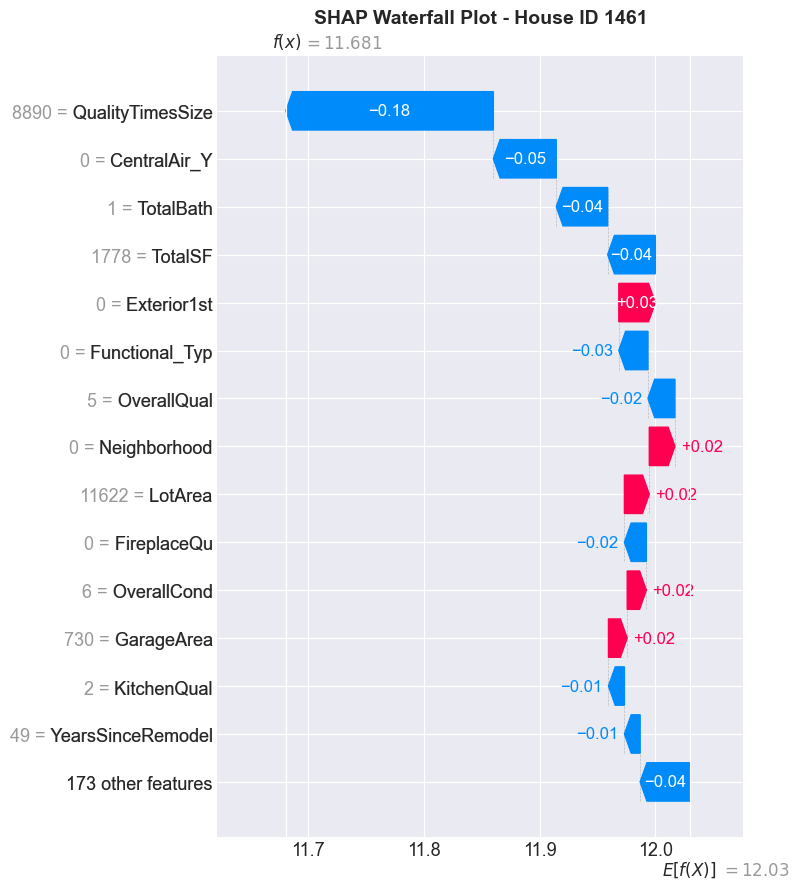


✓ Waterfall plot generated


In [42]:
# Create SHAP Waterfall Plot
print("\n" + "="*80)
print("SHAP WATERFALL PLOT")
print("="*80)

print("\nWaterfall plot shows:")
print("  - How each feature contributes to pushing the prediction")
print("  - From base value (average) to final prediction")
print("  - Red bars = increase price, Blue bars = decrease price")

fig = plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_exp, max_display=15, show=False)
plt.title(f'SHAP Waterfall Plot - House ID {selected_house_id}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Waterfall plot generated")


SHAP BAR PLOT - TOP FEATURES

Bar plot shows:
  - Top features by absolute impact
  - Positive values push price up, negative push down


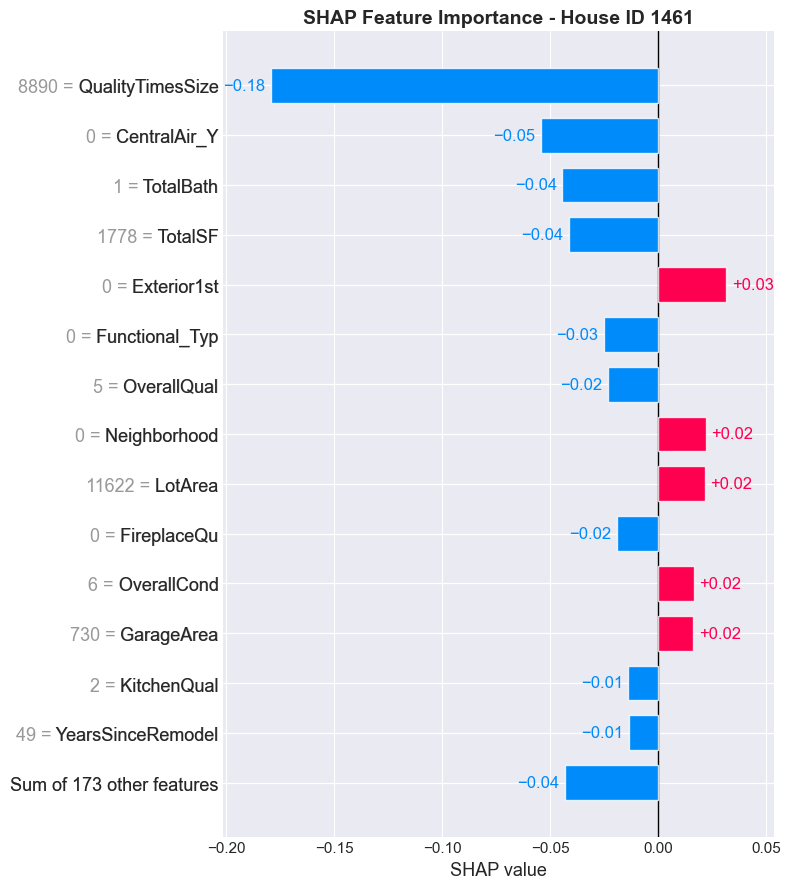


✓ Bar plot generated


In [43]:
# Create SHAP Bar Plot (easier to read than force plot)
print("\n" + "="*80)
print("SHAP BAR PLOT - TOP FEATURES")
print("="*80)

print("\nBar plot shows:")
print("  - Top features by absolute impact")
print("  - Positive values push price up, negative push down")

fig = plt.figure(figsize=(10, 8))
shap.plots.bar(shap_exp, max_display=15, show=False)
plt.title(f'SHAP Feature Importance - House ID {selected_house_id}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Bar plot generated")

## Summary and Recommendations

This notebook provides tools for:
1. **Single house price prediction** using trained models
2. **SHAP explanations** to understand why the model made its prediction
3. **Feature impact analysis** to identify which features matter most

### To use this notebook effectively:

1. **First, run Notebook 1** to train models and save them
2. **Prepare your house data** with the same preprocessing as training
3. **Use the prediction function** to get price estimates
4. **Generate SHAP explanations** to understand the prediction
5. **Perform what-if analysis** to explore scenarios

### Key Insights from SHAP:

- **Positive SHAP values** → Feature increases the predicted price
- **Negative SHAP values** → Feature decreases the predicted price
- **Magnitude** → How much the feature impacts the prediction
- **Base value** → Average model prediction across all houses

---

**Next Steps:**
- Use Notebook 3 to generate predictions for the entire test set
- Experiment with different houses to understand model behavior
- Use what-if analysis to provide recommendations to homeowners

## 6. Custom House Instance - Your Own Data

This section allows you to define your own house with just the key features you know.  
The system will automatically fill in defaults for any missing attributes.

In [44]:
def get_default_house_values():
    """
    Returns a dictionary with sensible default values for all house features.
    These defaults represent a typical/average house in the dataset.
    """
    defaults = {
        # Building type and zoning
        'MSSubClass': 60,  # 2-STORY 1946 & NEWER
        'MSZoning': 'RL',  # Residential Low Density
        
        # Lot details
        'LotFrontage': 70,
        'LotArea': 10000,
        'Street': 'Pave',
        'Alley': 'No_Alley',
        'LotShape': 'Reg',
        'LandContour': 'Lvl',
        'Utilities': 'AllPub',
        'LotConfig': 'Inside',
        'LandSlope': 'Gtl',
        
        # Neighborhood
        'Neighborhood': 'NAmes',
        'Condition1': 'Norm',
        'Condition2': 'Norm',
        'BldgType': '1Fam',
        'HouseStyle': '2Story',
        
        # Overall quality
        'OverallQual': 5,  # Average
        'OverallCond': 5,  # Average
        
        # Year information
        'YearBuilt': 1980,
        'YearRemodAdd': 1980,
        
        # Roof
        'RoofStyle': 'Gable',
        'RoofMatl': 'CompShg',
        
        # Exterior
        'Exterior1st': 'VinylSd',
        'Exterior2nd': 'VinylSd',
        'MasVnrType': 'None',
        'MasVnrArea': 0,
        'ExterQual': 'TA',  # Typical/Average
        'ExterCond': 'TA',
        
        # Foundation
        'Foundation': 'PConc',
        
        # Basement
        'BsmtQual': 'TA',
        'BsmtCond': 'TA',
        'BsmtExposure': 'No',
        'BsmtFinType1': 'Unf',
        'BsmtFinSF1': 0,
        'BsmtFinType2': 'Unf',
        'BsmtFinSF2': 0,
        'BsmtUnfSF': 800,
        'TotalBsmtSF': 800,
        'BsmtFullBath': 0,
        'BsmtHalfBath': 0,
        
        # Heating/Cooling
        'Heating': 'GasA',
        'HeatingQC': 'TA',
        'CentralAir': 'Y',
        'Electrical': 'SBrkr',
        
        # Living area
        '1stFlrSF': 800,
        '2ndFlrSF': 700,
        'LowQualFinSF': 0,
        'GrLivArea': 1500,
        
        # Bathrooms and rooms
        'FullBath': 2,
        'HalfBath': 0,
        'BedroomAbvGr': 3,
        'KitchenAbvGr': 1,
        'KitchenQual': 'TA',
        'TotRmsAbvGrd': 7,
        
        # Functional
        'Functional': 'Typ',
        
        # Fireplace
        'Fireplaces': 0,
        'FireplaceQu': 'No_Fireplace',
        
        # Garage
        'GarageType': 'Attchd',
        'GarageYrBlt': 1980,
        'GarageFinish': 'Unf',
        'GarageCars': 2,
        'GarageArea': 400,
        'GarageQual': 'TA',
        'GarageCond': 'TA',
        
        # Outdoor features
        'PavedDrive': 'Y',
        'WoodDeckSF': 0,
        'OpenPorchSF': 0,
        'EnclosedPorch': 0,
        '3SsnPorch': 0,
        'ScreenPorch': 0,
        'PoolArea': 0,
        'PoolQC': 'No_Pool',
        'Fence': 'No_Fence',
        'MiscFeature': 'None',
        'MiscVal': 0,
        
        # Sale information
        'MoSold': 6,
        'YrSold': 2010,
        'SaleType': 'WD',
        'SaleCondition': 'Normal',
    }
    
    return defaults


def create_custom_house(custom_features=None):
    """
    Create a house instance with custom features, filling missing values with defaults.
    
    Parameters:
    -----------
    custom_features : dict, optional
        Dictionary with feature names as keys and their values.
        Only specify features you know - all others will use defaults.
        
    Returns:
    --------
    pd.DataFrame : Single-row dataframe ready for prediction
    
    Example:
    --------
    my_house = create_custom_house({
        'OverallQual': 8,
        'GrLivArea': 2000,
        'YearBuilt': 2005,
        'GarageCars': 2,
        'FullBath': 2,
        'BedroomAbvGr': 4
    })
    """
    # Start with default values
    house_data = get_default_house_values()
    
    # Override with custom values if provided
    if custom_features:
        house_data.update(custom_features)
    
    # Create dataframe
    house_df = pd.DataFrame([house_data])
    
    # Add Id column (temporary, will be dropped later)
    house_df['Id'] = 9999
    
    return house_df


print("✓ Default values and custom house creation functions defined")
print("\nYou can now create a custom house with just the features you know!")
print("\nExample:")
print("  my_house = create_custom_house({")
print("      'OverallQual': 8,")
print("      'GrLivArea': 2500,")
print("      'YearBuilt': 2010")
print("  })")

✓ Default values and custom house creation functions defined

You can now create a custom house with just the features you know!

Example:
  my_house = create_custom_house({
      'OverallQual': 8,
      'GrLivArea': 2500,
      'YearBuilt': 2010
  })


### Example 1: Luxury Modern House

Create a high-quality, modern house with only the key features specified.

In [45]:
# Define your custom house - only specify what you know!
my_custom_house = create_custom_house({
    # Quality and condition
    'OverallQual': 9,          # Excellent quality
    'OverallCond': 8,          # Very good condition
    'ExterQual': 'Ex',         # Excellent exterior
    'KitchenQual': 'Ex',       # Excellent kitchen
    
    # Size and area
    'GrLivArea': 2800,         # 2,800 sq ft living area
    '1stFlrSF': 1400,          # First floor
    '2ndFlrSF': 1400,          # Second floor
    'TotalBsmtSF': 1400,       # Full basement
    'GarageArea': 600,         # 3-car garage
    'GarageCars': 3,
    
    # Rooms and baths
    'BedroomAbvGr': 4,         # 4 bedrooms
    'FullBath': 3,             # 3 full bathrooms
    'HalfBath': 1,             # 1 half bath
    'TotRmsAbvGrd': 9,         # 9 rooms above grade
    
    # Age
    'YearBuilt': 2015,         # Recently built
    'YearRemodAdd': 2015,
    
    # Lot
    'LotArea': 12000,          # 12,000 sq ft lot
    'LotFrontage': 85,
    
    # Location
    'Neighborhood': 'NoRidge', # North Ridge (premium neighborhood)
    
    # Additional features
    'Fireplaces': 1,
    'FireplaceQu': 'Gd',
    'CentralAir': 'Y',
    'BsmtQual': 'Ex',
    'BsmtFinType1': 'GLQ',     # Good Living Quarters
    'BsmtFinSF1': 1400,        # Finished basement
})

print("="*80)
print("CUSTOM HOUSE CREATED")
print("="*80)
print(f"\nSpecified {len([k for k in ['OverallQual', 'GrLivArea', 'YearBuilt', 'BedroomAbvGr', 'FullBath', 'Neighborhood', 'GarageCars', 'LotArea', 'Fireplaces', 'TotalBsmtSF'] if k in my_custom_house.columns])} key features")
print(f"Total features in dataset: {len(my_custom_house.columns)}")
print("\nKey features:")
print(f"  Overall Quality: {my_custom_house['OverallQual'].values[0]}")
print(f"  Living Area: {my_custom_house['GrLivArea'].values[0]:,} sq ft")
print(f"  Year Built: {int(my_custom_house['YearBuilt'].values[0])}")
print(f"  Bedrooms: {int(my_custom_house['BedroomAbvGr'].values[0])}")
print(f"  Full Baths: {int(my_custom_house['FullBath'].values[0])}")
print(f"  Garage Cars: {int(my_custom_house['GarageCars'].values[0])}")
print(f"  Neighborhood: {my_custom_house['Neighborhood'].values[0]}")
print(f"\n✓ All other features automatically filled with defaults")

CUSTOM HOUSE CREATED

Specified 10 key features
Total features in dataset: 80

Key features:
  Overall Quality: 9
  Living Area: 2,800 sq ft
  Year Built: 2015
  Bedrooms: 4
  Full Baths: 3
  Garage Cars: 3
  Neighborhood: NoRidge

✓ All other features automatically filled with defaults


In [46]:
# Process custom house through the same pipeline
print("\n" + "="*80)
print("PREPROCESSING CUSTOM HOUSE")
print("="*80)

# Apply preprocessing pipeline
custom_processed = preprocess_data(my_custom_house)
custom_encoded = encode_features(custom_processed)
custom_engineered = engineer_features(custom_encoded)

# Prepare features
custom_features = custom_engineered.drop(['Id'], axis=1, errors='ignore')

# Ensure all columns are numeric
for col in custom_features.select_dtypes(include=['object']).columns:
    custom_features[col] = pd.to_numeric(custom_features[col], errors='coerce').fillna(0)

# Align with training features
for feat in expected_features:
    if feat not in custom_features.columns:
        custom_features[feat] = 0

# Remove extra features and reorder
custom_features = custom_features[expected_features]

print(f"✓ Custom house preprocessed successfully")
print(f"Features shape: {custom_features.shape}")
print(f"Ready for prediction!")

# Make predictions
print("\n" + "="*80)
print("CUSTOM HOUSE PRICE PREDICTIONS")
print("="*80)

# XGBoost prediction
custom_xgb_pred_log = xgb_model.predict(custom_features)
custom_xgb_price = np.expm1(custom_xgb_pred_log[0])

# Elastic Net prediction (requires scaling)
custom_scaled = scaler.transform(custom_features)
custom_elastic_pred_log = elastic_model.predict(custom_scaled)
custom_elastic_price = np.expm1(custom_elastic_pred_log[0])

# Ensemble
custom_ensemble_price = (custom_xgb_price + custom_elastic_price) / 2

print(f"\nPredicted Prices for Your Custom House:")
print(f"  XGBoost:     ${custom_xgb_price:,.2f}")
print(f"  Elastic Net: ${custom_elastic_price:,.2f}")
print(f"  Ensemble:    ${custom_ensemble_price:,.2f}")
print(f"\n  Difference:  ${abs(custom_xgb_price - custom_elastic_price):,.2f}")
print(f"  Agreement:   {(1 - abs(custom_xgb_price - custom_elastic_price) / custom_ensemble_price) * 100:.1f}%")

print("\n✓ Custom house predictions complete!")


PREPROCESSING CUSTOM HOUSE
✓ Custom house preprocessed successfully
Features shape: (1, 187)
Ready for prediction!

CUSTOM HOUSE PRICE PREDICTIONS

Predicted Prices for Your Custom House:
  XGBoost:     $381,608.75
  Elastic Net: $329,012.69
  Ensemble:    $355,310.72

  Difference:  $52,596.06
  Agreement:   85.2%

✓ Custom house predictions complete!



SHAP ANALYSIS FOR CUSTOM HOUSE
✓ SHAP values calculated for custom house

Base prediction (average house): $167,755.95
Your house prediction: $381,608.75
Difference from average: $213,852.80


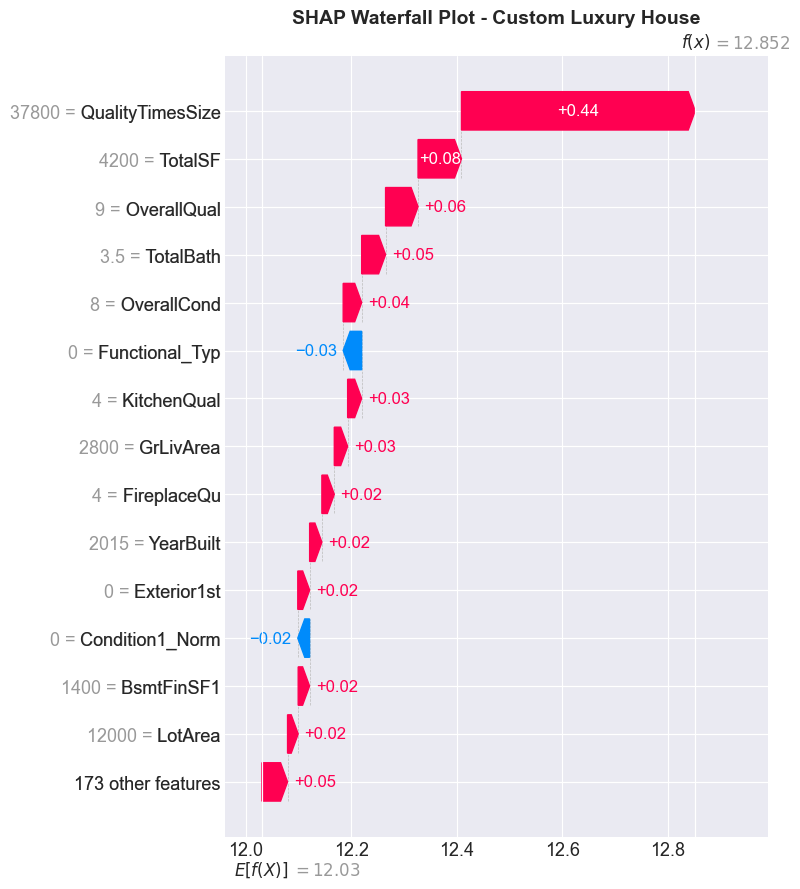


✓ SHAP waterfall plot generated


In [47]:
# Generate SHAP explanation for custom house
print("\n" + "="*80)
print("SHAP ANALYSIS FOR CUSTOM HOUSE")
print("="*80)

# Calculate SHAP values
custom_shap_values = explainer.shap_values(custom_features)

# Create SHAP explanation object
custom_shap_exp = shap.Explanation(
    values=custom_shap_values[0],
    base_values=explainer.expected_value,
    data=custom_features.iloc[0].values,
    feature_names=custom_features.columns.tolist()
)

print(f"✓ SHAP values calculated for custom house")
print(f"\nBase prediction (average house): ${np.expm1(explainer.expected_value):,.2f}")
print(f"Your house prediction: ${custom_xgb_price:,.2f}")
print(f"Difference from average: ${custom_xgb_price - np.expm1(explainer.expected_value):,.2f}")

# Waterfall plot
fig = plt.figure(figsize=(12, 8))
shap.plots.waterfall(custom_shap_exp, max_display=15, show=False)
plt.title('SHAP Waterfall Plot - Custom Luxury House', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ SHAP waterfall plot generated")

### Example 2: Minimal Input - Budget Starter Home

You can specify as few or as many features as you want!

In [48]:
# Create a house with just a few features
budget_house = create_custom_house({
    'OverallQual': 4,          # Below average
    'GrLivArea': 1000,         # Small house
    'YearBuilt': 1960,         # Older
    'BedroomAbvGr': 2,         # 2 bedrooms
    'GarageCars': 1,           # 1-car garage
})

print("="*80)
print("BUDGET STARTER HOME - MINIMAL INPUT")
print("="*80)
print("Only 5 features specified, all others use defaults!")
print(f"\n  Quality: {budget_house['OverallQual'].values[0]}")
print(f"  Size: {budget_house['GrLivArea'].values[0]:,} sq ft")
print(f"  Year: {int(budget_house['YearBuilt'].values[0])}")
print(f"  Bedrooms: {int(budget_house['BedroomAbvGr'].values[0])}")
print(f"  Garage: {int(budget_house['GarageCars'].values[0])} car")

# Preprocess and predict
budget_processed = preprocess_data(budget_house)
budget_encoded = encode_features(budget_processed)
budget_engineered = engineer_features(budget_encoded)
budget_features = budget_engineered.drop(['Id'], axis=1, errors='ignore')

# Ensure numeric
for col in budget_features.select_dtypes(include=['object']).columns:
    budget_features[col] = pd.to_numeric(budget_features[col], errors='coerce').fillna(0)

# Align features
for feat in expected_features:
    if feat not in budget_features.columns:
        budget_features[feat] = 0
budget_features = budget_features[expected_features]

# Predict
budget_xgb_price = np.expm1(xgb_model.predict(budget_features)[0])
budget_elastic_price = np.expm1(elastic_model.predict(scaler.transform(budget_features))[0])
budget_ensemble = (budget_xgb_price + budget_elastic_price) / 2

print(f"\n{'='*80}")
print("PRICE PREDICTION")
print("="*80)
print(f"  Ensemble Prediction: ${budget_ensemble:,.2f}")
print(f"\n✓ Successfully predicted with minimal input!")

BUDGET STARTER HOME - MINIMAL INPUT
Only 5 features specified, all others use defaults!

  Quality: 4
  Size: 1,000 sq ft
  Year: 1960
  Bedrooms: 2
  Garage: 1 car

PRICE PREDICTION
  Ensemble Prediction: $106,209.30

✓ Successfully predicted with minimal input!


### Helper Function: Streamlined Prediction

Create a convenient function to predict any custom house in one step.

In [49]:
def predict_custom_house(custom_features, show_details=True, show_shap=False):
    """
    Complete pipeline to predict price for a custom house.
    
    Parameters:
    -----------
    custom_features : dict
        Dictionary of house features (only specify what you know)
    show_details : bool
        Whether to print detailed information
    show_shap : bool
        Whether to generate SHAP explanation plots
        
    Returns:
    --------
    dict : Dictionary containing predictions and SHAP values
    
    Example:
    --------
    result = predict_custom_house({
        'OverallQual': 7,
        'GrLivArea': 1800,
        'YearBuilt': 2000
    })
    """
    # Create house with defaults
    house_df = create_custom_house(custom_features)
    
    # Preprocess
    processed = preprocess_data(house_df)
    encoded = encode_features(processed)
    engineered = engineer_features(encoded)
    features = engineered.drop(['Id'], axis=1, errors='ignore')
    
    # Ensure numeric
    for col in features.select_dtypes(include=['object']).columns:
        features[col] = pd.to_numeric(features[col], errors='coerce').fillna(0)
    
    # Align features
    for feat in expected_features:
        if feat not in features.columns:
            features[feat] = 0
    features = features[expected_features]
    
    # Predictions
    xgb_price = np.expm1(xgb_model.predict(features)[0])
    elastic_price = np.expm1(elastic_model.predict(scaler.transform(features))[0])
    ensemble_price = (xgb_price + elastic_price) / 2
    
    # SHAP values
    shap_vals = explainer.shap_values(features)
    shap_exp = shap.Explanation(
        values=shap_vals[0],
        base_values=explainer.expected_value,
        data=features.iloc[0].values,
        feature_names=features.columns.tolist()
    )
    
    # Print details
    if show_details:
        print("="*80)
        print("HOUSE PRICE PREDICTION")
        print("="*80)
        print(f"\nInput features specified: {len(custom_features)}")
        print(f"Total features used: {len(features.columns)}")
        print(f"\nPredicted Prices:")
        print(f"  XGBoost:     ${xgb_price:,.2f}")
        print(f"  Elastic Net: ${elastic_price:,.2f}")
        print(f"  Ensemble:    ${ensemble_price:,.2f}")
        print(f"\nBase value (average): ${np.expm1(explainer.expected_value):,.2f}")
        print(f"Difference: ${ensemble_price - np.expm1(explainer.expected_value):,.2f}")
    
    # SHAP plots
    if show_shap:
        print("\n" + "="*80)
        print("SHAP EXPLANATION")
        print("="*80)
        
        # Waterfall plot
        fig = plt.figure(figsize=(12, 8))
        shap.plots.waterfall(shap_exp, max_display=15, show=False)
        plt.title('SHAP Waterfall Plot - Custom House', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Bar plot
        fig = plt.figure(figsize=(10, 8))
        shap.plots.bar(shap_exp, max_display=15, show=False)
        plt.title('SHAP Feature Importance - Custom House', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    # Return results
    return {
        'xgb_price': xgb_price,
        'elastic_price': elastic_price,
        'ensemble_price': ensemble_price,
        'base_value': np.expm1(explainer.expected_value),
        'shap_values': shap_vals[0],
        'shap_explanation': shap_exp,
        'features': features
    }


print("✓ Streamlined prediction function created!")
print("\nUsage:")
print("  result = predict_custom_house({")
print("      'OverallQual': 7,")
print("      'GrLivArea': 2000,")
print("      'YearBuilt': 2005")
print("  }, show_details=True, show_shap=True)")

✓ Streamlined prediction function created!

Usage:
  result = predict_custom_house({
      'OverallQual': 7,
      'GrLivArea': 2000,
      'YearBuilt': 2005
  }, show_details=True, show_shap=True)


### Example 3: Quick Prediction with Streamlined Function

HOUSE PRICE PREDICTION

Input features specified: 10
Total features used: 187

Predicted Prices:
  XGBoost:     $141,280.69
  Elastic Net: $144,899.43
  Ensemble:    $143,090.06

Base value (average): $167,755.95
Difference: $-24,665.89

SHAP EXPLANATION


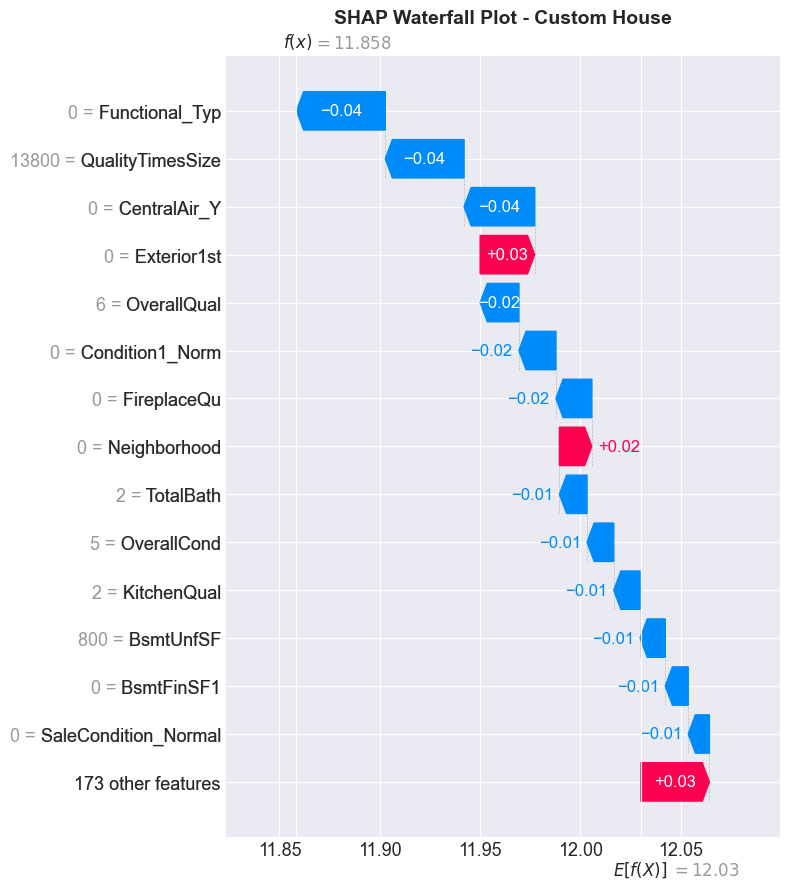

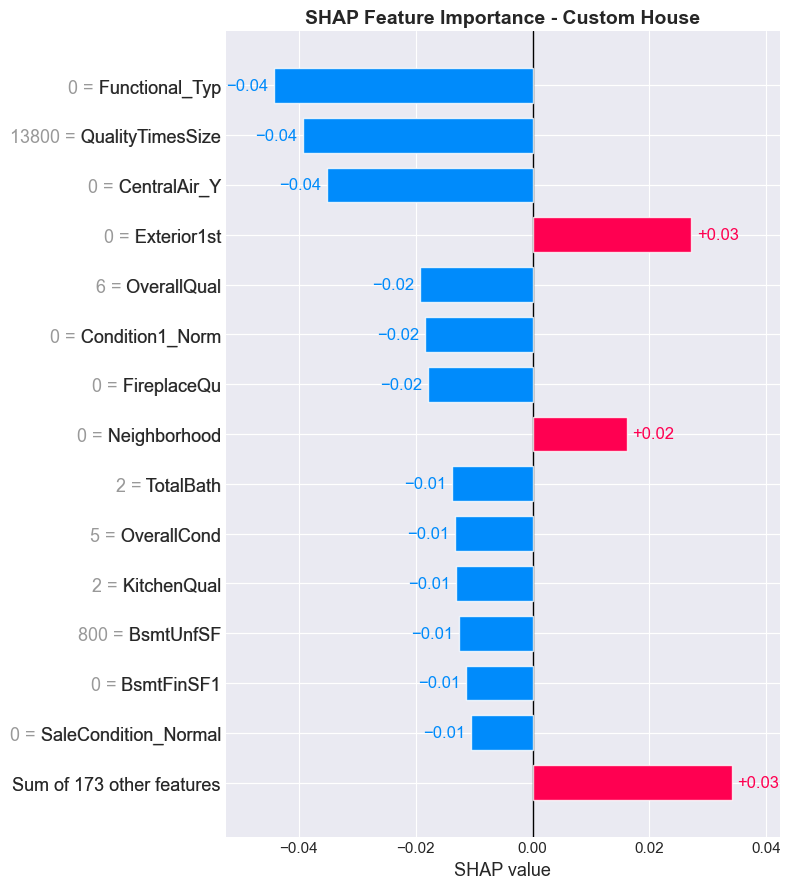


RESULT SUMMARY
Ensemble Price: $143,090.06
Price per sq ft: $77.35

Top 3 features increasing price:
  Exterior1st: +0.0272
  Neighborhood: +0.0161
  BsmtExposure_No: +0.0105


In [50]:
# Example: Mid-range family home
family_home_result = predict_custom_house(
    custom_features={
        'OverallQual': 6,        # Above average
        'GrLivArea': 1850,       # ~1,850 sq ft
        'YearBuilt': 1995,       # Built in 1995
        'BedroomAbvGr': 3,       # 3 bedrooms
        'FullBath': 2,           # 2 full baths
        'GarageCars': 2,         # 2-car garage
        'LotArea': 9500,         # ~9,500 sq ft lot
        'Neighborhood': 'CollgCr', # College Creek
        'CentralAir': 'Y',       # Central air
        'Fireplaces': 1,         # 1 fireplace
    },
    show_details=True,
    show_shap=True  # Set to False to skip SHAP plots
)

print("\n" + "="*80)
print("RESULT SUMMARY")
print("="*80)
print(f"Ensemble Price: ${family_home_result['ensemble_price']:,.2f}")
print(f"Price per sq ft: ${family_home_result['ensemble_price'] / 1850:.2f}")

# You can also access the SHAP explanation for further analysis
print(f"\nTop 3 features increasing price:")
top_features_idx = np.argsort(family_home_result['shap_values'])[-3:][::-1]
for idx in top_features_idx:
    if family_home_result['shap_values'][idx] > 0:
        print(f"  {family_home_result['shap_explanation'].feature_names[idx]}: +{family_home_result['shap_values'][idx]:.4f}")

### Comparison: Multiple Houses at Once

SCENARIO COMPARISON

         House Type Predicted Price vs Average
     Budget Starter     $110,220.64     -34.3%
Average Family Home     $129,113.18     -23.0%
     Modern Upgrade     $154,521.82      -7.9%
       Luxury House     $206,331.08     +23.0%


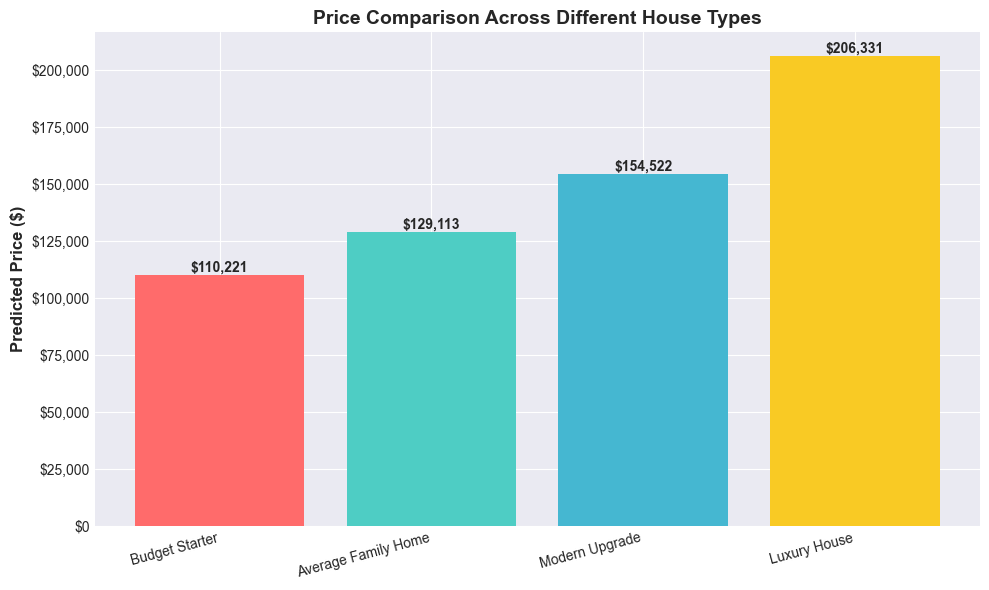


✓ Comparison complete!


In [51]:
# Compare different house scenarios
scenarios = [
    {
        'name': 'Budget Starter',
        'features': {
            'OverallQual': 4,
            'GrLivArea': 1000,
            'YearBuilt': 1960,
            'BedroomAbvGr': 2,
        }
    },
    {
        'name': 'Average Family Home',
        'features': {
            'OverallQual': 5,
            'GrLivArea': 1500,
            'YearBuilt': 1980,
            'BedroomAbvGr': 3,
            'GarageCars': 2,
        }
    },
    {
        'name': 'Modern Upgrade',
        'features': {
            'OverallQual': 7,
            'GrLivArea': 2000,
            'YearBuilt': 2005,
            'BedroomAbvGr': 3,
            'FullBath': 2,
            'GarageCars': 2,
        }
    },
    {
        'name': 'Luxury House',
        'features': {
            'OverallQual': 9,
            'GrLivArea': 2800,
            'YearBuilt': 2015,
            'BedroomAbvGr': 4,
            'FullBath': 3,
            'GarageCars': 3,
            'Neighborhood': 'NoRidge',
        }
    }
]

print("="*80)
print("SCENARIO COMPARISON")
print("="*80)

results = []
for scenario in scenarios:
    result = predict_custom_house(
        scenario['features'],
        show_details=False,
        show_shap=False
    )
    results.append({
        'House Type': scenario['name'],
        'Predicted Price': f"${result['ensemble_price']:,.2f}",
        'vs Average': f"{((result['ensemble_price'] / result['base_value'] - 1) * 100):+.1f}%"
    })

comparison_df = pd.DataFrame(results)
print("\n" + comparison_df.to_string(index=False))

# Visualization
prices = [float(r['Predicted Price'].replace('$', '').replace(',', '')) for r in results]
names = [r['House Type'] for r in results]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(names, prices, color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#f9ca24'])
ax.set_ylabel('Predicted Price ($)', fontsize=12, fontweight='bold')
ax.set_title('Price Comparison Across Different House Types', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.xticks(rotation=15, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:,.0f}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Comparison complete!")

---

## 🎯 Summary: Custom House Prediction System

### Key Features Added:

1. **Default Values System** 
   - `get_default_house_values()` provides sensible defaults for all 80+ features
   - Represents a typical average house in the dataset

2. **Flexible Input**
   - `create_custom_house(custom_features)` accepts ANY subset of features
   - Automatically fills missing values with defaults
   - Works with as few as 1 feature or all features

3. **Streamlined Prediction**
   - `predict_custom_house()` handles complete pipeline in one function
   - Preprocessing → Encoding → Feature Engineering → Prediction → SHAP
   - Optional detailed output and SHAP visualizations

4. **Real-World Usage**
   - No need to know all 80+ features
   - Specify only what you know about a house
   - Perfect for quick estimates and comparisons

### How It Works:

```python
# Minimal example - just 3 features!
result = predict_custom_house({
    'OverallQual': 7,
    'GrLivArea': 2000,
    'YearBuilt': 2005
})
```

All other features automatically use sensible defaults, ensuring:
- ✓ Models run without errors
- ✓ Predictions are reasonable
- ✓ SHAP explanations work correctly
- ✓ Easy to use for anyone

### Next Steps:
- Try predicting your own house!
- Experiment with different feature combinations
- Use SHAP to understand what drives prices
- Compare different scenarios